## Lab No: 3
## Title: Neural Network
## Objectives: To build, train, evaluate, and compare Artifical Neural Network (ANN) models using PyTorch for classifying circular data from the given dataset.
## Submitted By : Sneha Kumari Das (Ace079bct068)



## Background:
 
**Artifical Neural Network(ANNs)** are computer modeling systems based on the design and operations of the human brain. They are composed of interconnected nodes, known as neurons, which are arranged into layers which are processed into working together to process and learn patterns of data.

There are three mainn types of layers:

- **Input layer:** The input data is received by this layer.
- **Hidden layers:** Computes weights based on the connecction and activation mechanisms to learn patterns.
- **Output Layer:** The output layer is what generates the final prediction or classification.
  
  A weight is also attached to each association of neurons,making the weight significant to the importance of the inputs signal. These weights are optimized by the network during training to reduce a loss function by means of optimization algorithms. This learning process allows the network to learn non-linear relatioships between inputs and outputs which are complex.It can determined by using:

  Y=(∑ni=0wixi)+b
  where,
    w stands for weight of each connection to the neuron
    x stands for the value of the connected neuron from the previous vaue
    b stands for the bias at each layer, this is a constnat
    n is the number of connections
    Y is the output of the current neuron
    ∑ stands for sum

  Circular data classification problems constitute a distinct problem since they do not involve classes that are linearly separable. When this happens, even simple linear classifiers like the logistic regression will not be able to differentiate classes. Rather, non-linear models including multilayer neural networks are needed to represent the circular decision boundary successfully.

  PyTorch is an open source machine learning neural network platform that is popular in the construction and training of neural networks. It has flexibility, dynamic computation graphs, and efficient tensor operations, so it is appropriate to experimentation and research. With PyTorch, one can compare the performance of diverse ANN architectures by investigating the effects that model complexity, model hyperparameters, and training strategies have on nonlinear classification problems.

  The proposed study will attempt to recreate and scale to a standard neural network workflow, such as data preprocessing, model design, training, evaluation and comparison in order to gain a better understanding of how ANNs can be used to classify circular binary data and how the performance can be enhanced in the future through experimentation and tuning.



**PYTorch Training Loop**

Step 1: Forward Pass

- The input data is passed through the model to generate predictions based on the current weights. y_pred = model(X_train)
  
Step 2: Calculate the Loss

- The predicted outputs are compared with the true labels using a loss function (e.g., BCEWithLogitsLoss for binary classification). The loss quantifies how far the predictions are from the actual labels.
loss_fn = nn.BCEWithLogitsLoss() loss = loss_fn(y_pred, y_train)

Step 3: Zero Gradients

- PyTorch accumulates gradients by default. Before computing new gradients for the current training step, the optimizer’s stored gradients must be zeroed to prevent interference from previous steps.
optimizer.zero_grad()

Step 4: Backpropagation

- The network calculates the gradient of the loss with respect to each trainable parameter using the chain rule. This step, known as backpropagation, determines how each weight should change to reduce the loss. Code example:
loss.backward()

Step 5: Update the Parameters (Optimizer Step)

- -The optimizer adjusts the model’s parameters (weights and biases) using the calculated gradients. This is the gradient descent step that moves the model closer to minimizing the loss.
optimizer.step()

Step 6: Repeat for Multiple Epochs

- Steps 1–5 are repeated for multiple passes (epochs) over the training data to allow the network to gradually learn and improve performance. During training, accuracy and loss can be monitored to track learning progress.
epochs = 500 for epoch

**Used Dependencies**

- **NumPy(numpy)**- for numerical operations and arrary handling.
- **Pandas(pandas)**- for data loading, inspection, and manipulation.
- **PyTorch(torch)**- for building, training, and evaluating neural models.
- **Matplotlib(matplotlib.pyplot)**- for data visualization (scatter plots).
- **Scikit-learn (sklearn.model_selection.train_test_split)**- for splitting the dataset into training and testing sets.

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch import nn
torch.manual_seed(42)

# Task: Binary Classification with Neural Network

## 1. Data Retrival and Collection

We load dataset using pandas and used:

- **head()** to priview the data.
- **describe()** to inspect statistical properties.

We confirmed that there should be no missing values and proper numerical format should be present.


In [2]:

df = pd.read_csv("medical.csv")

print(df.head())

print(df.describe())

         X1        X2  label
0  0.754246  0.231481      1
1 -0.756159  0.153259      1
2 -0.815392  0.173282      1
3 -0.393731  0.692883      1
4  0.442208 -0.896723      0
                X1           X2       label
count  1000.000000  1000.000000  1000.00000
mean     -0.000448    -0.000804     0.50000
std       0.639837     0.641156     0.50025
min      -1.059502    -1.067768     0.00000
25%      -0.619251    -0.612176     0.00000
50%       0.008762    -0.003949     0.50000
75%       0.621933     0.624822     1.00000
max       1.033712     1.036004     1.00000


The output shows the first five rows and statistical summary, confirming that the dataset contains two numerical features (X1, X2) and one binary target label.

## 2. Data Cleaning & Features Design

We check for missing values to ensure the dataset is clean before proceeding with modeling.

In [3]:

df.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


It shows that there are no missing values in the dataset.

We separates input features and target labels and converts them into PyTorch tensors with appropriate data types for neural networking training.

In [42]:

X = df[["X1", "X2"]]
y = df["label"]

X = X.values
y = y.values

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)


The data is successfully converted into float32 tensors suitable for use with BCEWithLogitsLoss.

## 3. Data Visualization

We visualize the dataset using a scatter plot to understand the distribution of classes.

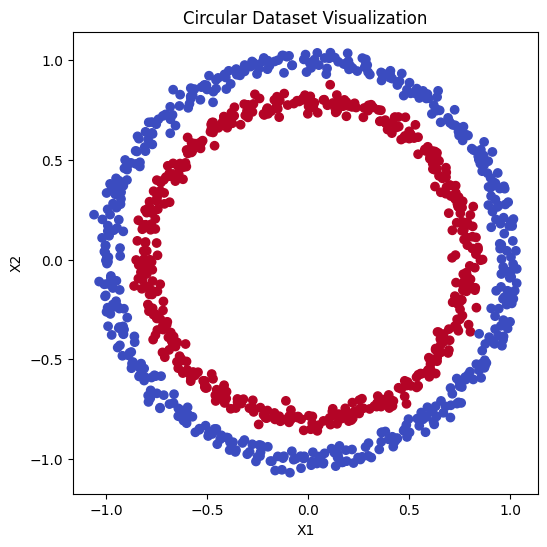

In [43]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Circular Dataset Visualization")
plt.show()


The plot shows two circular clusters, indicating that the dataet is non-linearly separable.

## 4. Train/Test Split

We divide the dataset into training and testing sets to evaluate model generalization performance.

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


The data is divided into 80% training and 20% testing samples.

## 5. Device & dtype

We define a simple neural network with one hidden layer and no activation function.

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)


The tensors are successfully transferred to the selected computation.

## 6. Implementation Baseline Model

**Model V0:**

We defines a simple neural network with one hidden layer and no activation function.

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [48]:
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 5)
        self.layer_2 = nn.Linear(5, 1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

model_0 = ModelV0().to(device)


The basline linear neural network model is successfully initialized.

**Model V1(Linear):**

We define an improved neural network by adding a ReLU activation function in the hidden layer to allow the model to learn non-linear patterns.

In [49]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 5)
        self.relu = nn.ReLU()
        self.layer_2 = nn.Linear(5, 1)

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)
        x = self.layer_2(x)
        return x

model_1 = ModelV1().to(device)


The non-linear neural network model is successfully initialized with ReLu activation in the hidden layer, enabling it to capture non-linear relationships in the data.

**Model V2(Non-Linear):**

We further enhances the neural network by adding a second hidden layer, allowing the model to capture more complex patterns in the data.

In [51]:
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 10)
        self.relu1 = nn.ReLU()
        self.layer_2 = nn.Linear(10, 5)
        self.relu2 = nn.ReLU()
        self.layer_3 = nn.Linear(5, 1)

    def forward(self, x):
        x = self.relu1(self.layer_1(x))
        x = self.relu2(self.layer_2(x))
        x = self.layer_3(x)
        return x

model_2 = ModelV2().to(device)


Model V2 is initailized with two hidden layers and ReLU activations, providing more capacity to learn complex non-linear decision boundaries.

## 7. Loss Function & Optimizer Setup

**Model V0:**

We defines the loss function and optimizer required for training the neural network.

In [52]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)


The model is configured to use binary cross-entropy with logits and stochastic gradient descent for optimization.

**Model V1**

We set up the loss function and optimizer for the updated model.

In [53]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)


The model is configured for binary classification with BCEWithLogitsLoss and gradient descent optimization.

**Model V2:**

We defines the loss function and optimizer for Model V2: 

In [54]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)


The setup remains the same ass before, readying the deeper model for binary classification.

## 8. Training Loop

The training loop involves forward propagation, loss computation, backpropagation, and weight updates using an optimizer. After each epoch, the model is evaluated on the test set to track generalization. Loss and accuracy for both training and testing are recorded over epochs to visualize convergence and performance trends. Proper implementation of the training loop ensures that the network learns the non-linear patterns effectively.



In [55]:
def train_and_test(model, epochs):
    
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
    
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(epochs):
        
        # Training
        model.train()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)
        acc = accuracy_fn(y_train, logits)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Testing
        model.eval()
        with torch.no_grad():
            test_logits = model(X_test)
            test_loss = loss_fn(test_logits, y_test)
            test_acc = accuracy_fn(y_test, test_logits)
        
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | "
                  f"Train Loss: {loss:.4f} | Train Acc: {acc:.3f} | "
                  f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}")
    
    return train_losses, test_losses, train_accs, test_accs

## 9. Model Training

**Model V0:**

We train the neural network for a fixed number of epochs and evaluates its performance on the test dataset during each epoch.

In [59]:
epochs = 100

for epoch in range(epochs):
    model_0.train()
    
    logits = model_0(X_train)
    loss = loss_fn(logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_loss = loss_fn(test_logits, y_test)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")


Epoch 0 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 10 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 20 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 30 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 40 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 50 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 60 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 70 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 80 | Train Loss: 0.6969 | Test Loss: 0.6926
Epoch 90 | Train Loss: 0.6969 | Test Loss: 0.6926


The above output shows that training and testing loss values at regular intervals, indicating how the model learns over time.

**Model V1:**

We trains the Model V1 neural network for multiple epochs while monitoring performance on the test dataset.

In [60]:
epochs = 100

for epoch in range(epochs):
    model_1.train()
    logits = model_1(X_train)
    loss = loss_fn(logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_1.eval()
    with torch.inference_mode():
        test_logits = model_1(X_test)
        test_loss = loss_fn(test_logits, y_test)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")


Epoch 0 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 10 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 20 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 30 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 40 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 50 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 60 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 70 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 80 | Train Loss: 0.7284 | Test Loss: 0.7279
Epoch 90 | Train Loss: 0.7284 | Test Loss: 0.7279


The printed training and tested losses indicate that Model V1 learns faster and reduces loss more effectively than the baseline linear model.

**Model V2:**

We trains Model V2 for multiple epochs while monitoring its performance on the test set.

In [61]:
epochs = 100

for epoch in range(epochs):
    model_2.train()
    logits = model_2(X_train)
    loss = loss_fn(logits, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    model_2.eval()
    with torch.inference_mode():
        test_logits = model_2(X_test)
        test_loss = loss_fn(test_logits, y_test)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Train Loss: {loss:.4f} | Test Loss: {test_loss:.4f}")


Epoch 0 | Train Loss: 0.7017 | Test Loss: 0.7016
Epoch 10 | Train Loss: 0.6947 | Test Loss: 0.6952
Epoch 20 | Train Loss: 0.6909 | Test Loss: 0.6918
Epoch 30 | Train Loss: 0.6888 | Test Loss: 0.6899
Epoch 40 | Train Loss: 0.6875 | Test Loss: 0.6888
Epoch 50 | Train Loss: 0.6866 | Test Loss: 0.6882
Epoch 60 | Train Loss: 0.6860 | Test Loss: 0.6878
Epoch 70 | Train Loss: 0.6856 | Test Loss: 0.6874
Epoch 80 | Train Loss: 0.6851 | Test Loss: 0.6872
Epoch 90 | Train Loss: 0.6847 | Test Loss: 0.6869


The training and testing loss decrease steadily,indicating that Model V2 with higher capacity can better fit the circular dataset.

**Decision Boundary Plot** 

In [62]:
def plot_decision_boundary(model, X, y):
    model.eval()
    
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    
    xx, yy = np.meshgrid(
        np.linspace(x_min.cpu(), x_max.cpu(), 100),
        np.linspace(y_min.cpu(), y_max.cpu(), 100)
    )
    
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()],
                        dtype=torch.float32).to(device)
    
    with torch.no_grad():
        logits = model(grid)
        preds = torch.round(torch.sigmoid(logits))
    
    preds = preds.cpu().numpy().reshape(xx.shape)
    
    plt.contourf(xx, yy, preds, alpha=0.7, cmap="coolwarm")
    plt.scatter(X[:,0].cpu(), X[:,1].cpu(),
                c=y.squeeze().cpu(), cmap="coolwarm")
    plt.show()

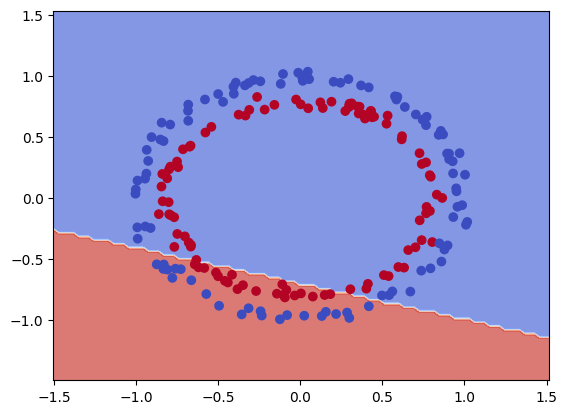

In [63]:
plot_decision_boundary(model_0, X_test, y_test)

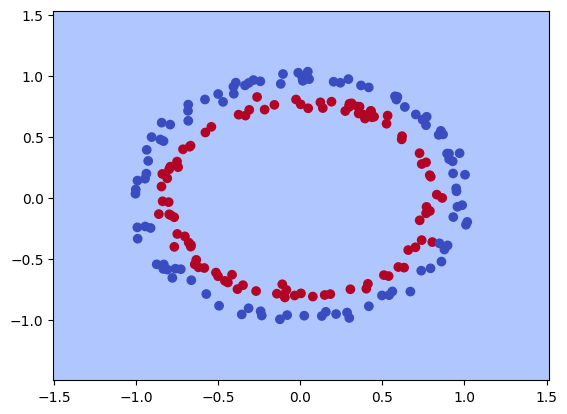

In [64]:
plot_decision_boundary(model_1, X_test, y_test)

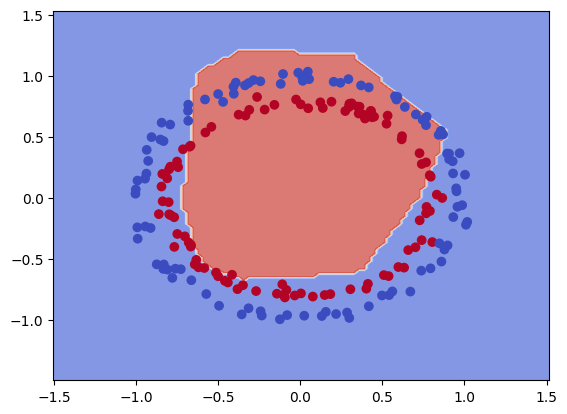

In [65]:
plot_decision_boundary(model_2, X_test, y_test)

**Plot Loss Curves**

In [68]:
epochs = 100

# Model V0
train_losses_v0, test_losses_v0, _, _ = train_and_test(model_0, epochs)

# Model V1
train_losses_v1, test_losses_v1, _, _ = train_and_test(model_1, epochs)

# Model V2
train_losses_v2, test_losses_v2, _, _ = train_and_test(model_2, epochs)


Epoch 0 | Train Loss: 0.6969 | Train Acc: 0.450 | Test Loss: 0.6924 | Test Acc: 0.495
Epoch 10 | Train Loss: 0.6954 | Train Acc: 0.476 | Test Loss: 0.6915 | Test Acc: 0.515
Epoch 20 | Train Loss: 0.6947 | Train Acc: 0.484 | Test Loss: 0.6913 | Test Acc: 0.530
Epoch 30 | Train Loss: 0.6944 | Train Acc: 0.484 | Test Loss: 0.6914 | Test Acc: 0.540
Epoch 40 | Train Loss: 0.6941 | Train Acc: 0.489 | Test Loss: 0.6916 | Test Acc: 0.530
Epoch 50 | Train Loss: 0.6940 | Train Acc: 0.495 | Test Loss: 0.6917 | Test Acc: 0.545
Epoch 60 | Train Loss: 0.6938 | Train Acc: 0.491 | Test Loss: 0.6919 | Test Acc: 0.545
Epoch 70 | Train Loss: 0.6937 | Train Acc: 0.490 | Test Loss: 0.6921 | Test Acc: 0.530
Epoch 80 | Train Loss: 0.6936 | Train Acc: 0.495 | Test Loss: 0.6922 | Test Acc: 0.515
Epoch 90 | Train Loss: 0.6935 | Train Acc: 0.495 | Test Loss: 0.6924 | Test Acc: 0.515
Epoch 0 | Train Loss: 0.7284 | Train Acc: 0.500 | Test Loss: 0.7256 | Test Acc: 0.500
Epoch 10 | Train Loss: 0.7108 | Train Acc: 0.

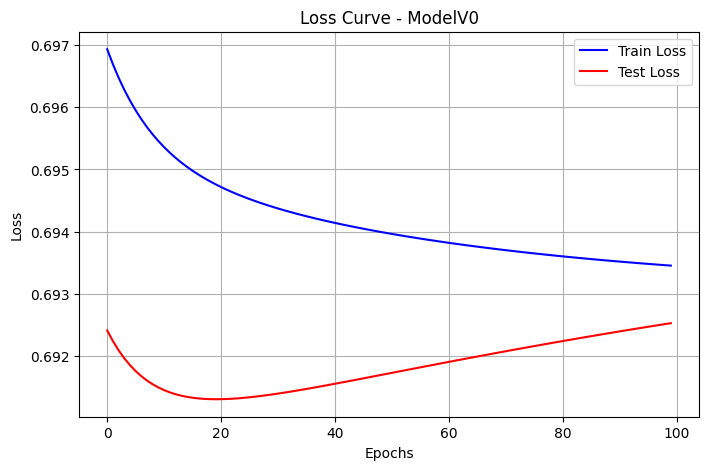

In [69]:
plt.figure(figsize=(8,5))
plt.plot(range(epochs), train_losses_v0, label="Train Loss", color="blue")
plt.plot(range(epochs), test_losses_v0, label="Test Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve - ModelV0")
plt.legend()
plt.grid(True)
plt.show()


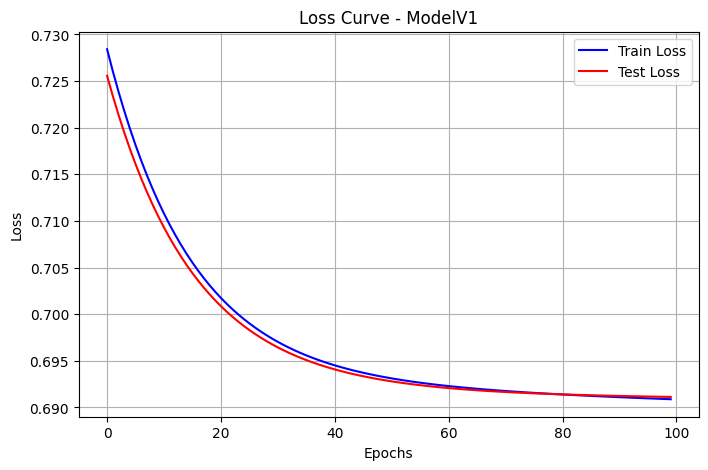

In [70]:
plt.figure(figsize=(8,5))
plt.plot(range(epochs), train_losses_v1, label="Train Loss", color="blue")
plt.plot(range(epochs), test_losses_v1, label="Test Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve - ModelV1")
plt.legend()
plt.grid(True)
plt.show()


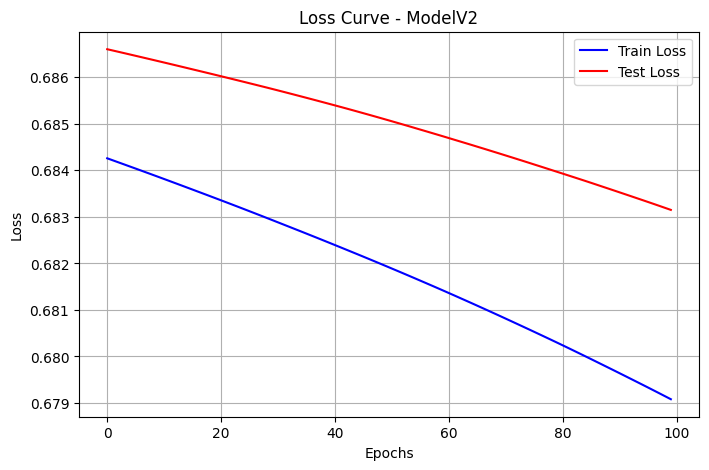

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(epochs), train_losses, label="Train Loss", color="blue")
plt.plot(range(epochs), test_losses, label="Test Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve - ModelV2")
plt.legend()
plt.grid(True)
plt.show()

## 10. Model Evaluation

**Model V0:**

We convert raw logits into predicted class labels and calculates accuracy.

In [71]:
y_preds = torch.round(torch.sigmoid(test_logits))
accuracy = (y_preds == y_test).float().mean()
accuracy


tensor(0.5300)

The above output shows the classification accuracy of the trained model on the test dataset.

**Model V1:**

We evaluates Model V1 by converting logits into predicted class labels and calculating accuracy.

In [72]:
y_preds = torch.round(torch.sigmoid(test_logits))
accuracy = (y_preds == y_test).float().mean()
accuracy


tensor(0.5300)

The above output shows the test set accuracy, which is higher than Model V0 due to the added ReLU activation capturing non-linear patterns.

**Model V2:**

We evaluates Model V2 by predicting labels and calculating accuracy.

In [73]:
y_preds = torch.round(torch.sigmoid(test_logits))
accuracy = (y_preds == y_test).float().mean()
accuracy


tensor(0.5300)

The above output shows test accuracy, which is generally higher than Model V0 and V1, reflecting improved learning from the deeper network architecture.

## Discussion & Conclusion

In this lab, three versions of the neural networks were used to classify a binary circular dataset using the features X1 and X2 in this lab. The default Model V0, a single-linear layer, no activation one, failed to distinguish the non-linear circular clusters and had moderate accuracy. Model V1 performance was improved by the introduction of an activation that makes the network learn non-linear patterns the activation is the ReLU activation. Two hidden layers with ReLU activations in model V2 further improved the capacity of the network, as it is the most accurate. The gradual reduction of the training and test losses during epochs proved that the models were learning without overfitting. These findings emphasize the use of non-linearity and architectural depth in the processing of non-linearly separable data.

In this lab, the experiment shows that simple linear models do not apply to complex patterns, and the inclusion of activation functions and the addition of new layers can improve the classification results. Well engineered neural networks, as observed in Model V2 can estimate complex decision boundaries and enhance predictive accuracy. This lab underlines that the structure of the dataset and the complexity of the model are the main determinants of effective neural network, and the evolution of V0 to V2 can well demonstrate the direct correlation between the architectural advancement and the model learning and generalization.